## **[실습-1] 주요 대학별 2026학년도 수시2차 실시간 지원현황 데이터 분석하기**
#### > 주요 대학의 **'전형별 경쟁률 현황'** \<table>을 스크랩핑하여 분석한다.
#### 0. 주요 대학의 2026학년도 수시2차 실시간 지원현황 페이지를 방문하여 페이지 정보 알아보기
> 부천대학교, 유한대학교, 연성대학교, 대림대학교, 동서울대학교, , 동양미래대학교
#### 1. 전체 경쟁률 현황을 데이터 프레임으로 구축하기
> 대학명, 경쟁률 페이지 url, 분석 대상 table의 index 사용
##### > **[실습] 웹 페이지에서 원하는 \<table>의 데이터를 수집해주는 함수를 만들어 사용**
#### 2. 추출된 데이터에 대한 정제 
##### > 불필요한 컬럼 제거
> ['전형', '모집인원', '지원인원', '경쟁률']와 관련된 컬럼만 남기고 제거
##### > 컬럼명 통일
> ['전형', '모집인원', '지원인원', '경쟁률']로 통일
##### > '대학' 컬럼 추가
##### > 대학별 데이터 행들을 하나의 데이터 프레임으로 통합
##### > 경쟁률 데이터 값 보정하기
> 후반부의 ' : 1' 값 제거\
> 자료형을 float로 변경
##### > 불필요한 행 제거
> '전형' 컬럼에 '총계'나 '소계' 값이 들어있는 행은 삭제\
> 문자열에서 찾는 문자열의 시작 위치 값 찾기 : **str.find()**
##### > 컬럼 순서 조정
> ['대학', '전형', '모집인원', '지원인원', '경쟁률'] 순으로 조정

#### 3. [분석] 대학별 합계 합계 경쟁률 데이터 구축
> 대학별 모집인원, 지원인원, 총지원인원, 경쟁률 컬럼으로 구성\
> 경쟁률이 높은 순으로 보기
#### 4. [분석] 대학별 합계 합계 경쟁률 비교 그래프 그리기
> 대학별 합계 경쟁률 순위 막대 그래프 그리기\
> 대학별 합계 지원자 수 순위 막대 그래프 그리기

----

#### **0. 주요 대학의 2026학년도 수시2차 실시간 지원현황 페이지를 방문하여 페이지 정보 알아보기**
> 부천대학교, 유한대학교, 연성대학교, 대림대학교, 동서울대학교, 동양미래대학교

In [4]:
## [부천대학교] URL로 웹 페이지 열어보기
import webbrowser as wb
url = 'https://ratio.uwayapply.com/SmZKTEJKZkNDYUxKLWZUZg=='
wb.open_new(url)  #브라우저에 사이트가 열림

True

##### 함수 만들기 : URL로 웹 페이지 열어보기

In [1]:
## [함수 만들기] URL로 웹 페이지 열어보기
def open_page(url='https://www.example.com'):
    import webbrowser as wb
    wb.open_new(url)  #브라우저에 사이트가 열림

In [2]:
## [함수 호출] URL로 웹 페이지 열어보기
url = 'https://ratio.uwayapply.com/SmZKTEJKZkNDYUxKLWZUZg=='
open_page(url)

#### **1. 전형별 경쟁률 현황을 데이터 프레임으로 구축하기**
> 대학명, 경쟁률 페이지 url, 분석 대상 table의 index 사용

#### [부천대학교] 해당 페이지의 \<table> 데이터를 받아 데이터 프레임 구축
> 원하는 \<table> 데이터만 추출

In [5]:
## [부천대학교] 경쟁률 현황을 데이터 프레임으로 구축하기
import pandas as pd
import urllib3  

url = 'https://ratio.uwayapply.com/SmZKTEJKZkNDYUxKLWZUZg==' 
header = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3',
    'Referer': url
} 
index = 1  # 전형별 경쟁률 현황

# 웹 페이지에서 표 스크래핑
http = urllib3.PoolManager()  #http나 https 연결 관리자 호출
req = http.request('GET', url, headers=header)  #http 연결 관리자로 html 문서 요청
tables = pd.read_html(req.data)  #html 문서에서 테이블 태그(<table> </table>) 부분의 값들을  list 형태(table 개수만큼)로 반환

df_a = tables[index]  #데이터 프레임
df_a.head()

,캠퍼스,모집단위,모집인원,지원인원,경쟁률,학과소개
0,본캠퍼스,건축과(3년제),17,234,13.76 : 1,NaN
1,본캠퍼스,실내건축디자인학과(3년제),16,176,11.00 : 1,NaN
2,본캠퍼스,토목공학과,19,132,6.95 : 1,NaN
3,본캠퍼스,정보통신과,18,157,8.72 : 1,NaN
4,본캠퍼스,전자공학과 전자공학전공,10,89,8.90 : 1,NaN


#### [유한대학교] URL로 웹 페이지 열어보기

In [6]:
## [유한대학교] URL로 웹 페이지 열어보기
url = 'https://ratio.uwayapply.com/SmZKVzh8OmJKZkNDYUxKLWZUZg=='
open_page(url)

#### [유한대학교] 해당 페이지의 \<table> 데이터를 받아 데이터 프레임 구축
> 원하는 \<table> 데이터만 추출

#### **[실습] 웹 페이지에서 원하는 \<table>의 데이터를 수집해주는 함수를 만들어 사용**
> 함수로 수집할 대학의 url과 \<table> index 값, header 값을을 넘겨서 호출함(단, header 값은 생략 가능하게)\
> 함수는 url에 해당하는 페이지에서 index에 해당하는 \<table> 값만으로 데이터 프레임을 구성해서 반환

In [7]:
## [함수 만들기] 경쟁률 현황을 데이터 프레임으로 구축하여 반환
def get_table(url, index=0, header=None):
    import pandas as pd
    import urllib3  

    # 웹 페이지에서 표 스크래핑
    http = urllib3.PoolManager()  #http나 https 연결 관리자 호출
    req = http.request('GET', url, headers=header)  #http 연결 관리자로 html 문서 요청
    tables = pd.read_html(req.data)  #html 문서에서 테이블 태그(<table> </table>) 부분의 값들을  list 형태(table 개수만큼)로 반환

    return tables[index]  #데이터 프레임으로 반환

In [17]:
## [유한대학교] 경쟁률 현황을 데이터 프레임으로 구축하기
url = 'https://ratio.uwayapply.com/SmZKVzh8OmJKZkNDYUxKLWZUZg=='  
header = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3',
    'Referer': url
} 
index = 1  # 전형별 경쟁률 현황
df_b = get_table(url, index=index, header=header)
df_b.head()

,모집단위(주간),모집인원,지원인원,경쟁률,학과홈페이지
0,자유전공학과,7,95,13.57 : 1,NaN
1,기계공학전공,5,129,25.80 : 1,NaN
2,소방설비안전전공,5,95,19.00 : 1,NaN
3,전기공학전공,6,81,13.50 : 1,NaN
4,전자공학전공,6,61,10.17 : 1,NaN


#### **2. 추출된 데이터에 대한 정제**

##### **불필요한 컬럼 제거**
##### > ['전형', '모집인원', '지원인원', '경쟁률']와 관련된 컬럼만 남기고 제거
> df = df.drop( '구분', axis = 'columns')\
> del df_a['구분']

In [12]:
#### [부천대학] 데이터 확인
df_a.head()

,캠퍼스,모집단위,모집인원,지원인원,경쟁률,학과소개
0,본캠퍼스,건축과(3년제),17,234,13.76 : 1,NaN
1,본캠퍼스,실내건축디자인학과(3년제),16,176,11.00 : 1,NaN
2,본캠퍼스,토목공학과,19,132,6.95 : 1,NaN
3,본캠퍼스,정보통신과,18,157,8.72 : 1,NaN
4,본캠퍼스,전자공학과 전자공학전공,10,89,8.90 : 1,NaN


##### **열 선택: [모집단위,	모집인원,	지원인원,	경쟁률]**

In [13]:
## 후반 작업 : 열 선택
df_a = df_a.iloc[:, [1, 2, 3, 4]] 
df_a.head()

,모집단위,모집인원,지원인원,경쟁률
0,건축과(3년제),17,234,13.76 : 1
1,실내건축디자인학과(3년제),16,176,11.00 : 1
2,토목공학과,19,132,6.95 : 1
3,정보통신과,18,157,8.72 : 1
4,전자공학과 전자공학전공,10,89,8.90 : 1


##### **컬럼명 통일**
> ['전형', '모집인원', '지원인원', '경쟁률']로 통일

In [14]:
#### [부천대학] 컬럼명 통일시키기
## ['구분', '전형', '모집인원', '지원인원', '경쟁률']로 컬럼명 통일
new_cols = ['전형', '모집인원', '지원인원', '경쟁률']
df_a.columns = new_cols 

df_a.head()

,전형,모집인원,지원인원,경쟁률
0,건축과(3년제),17,234,13.76 : 1
1,실내건축디자인학과(3년제),16,176,11.00 : 1
2,토목공학과,19,132,6.95 : 1
3,정보통신과,18,157,8.72 : 1
4,전자공학과 전자공학전공,10,89,8.90 : 1


##### **'대학' 컬럼 추가**

In [15]:
## [부천대학] 대학 열 추가
df_a['대학'] = '부천대학교'
df_a.head()

C:\Users\User\AppData\Local\Temp\ipykernel_4392\3785123579.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_a['대학'] = '부천대학교'


,전형,모집인원,지원인원,경쟁률,대학
0,건축과(3년제),17,234,13.76 : 1,부천대학교
1,실내건축디자인학과(3년제),16,176,11.00 : 1,부천대학교
2,토목공학과,19,132,6.95 : 1,부천대학교
3,정보통신과,18,157,8.72 : 1,부천대학교
4,전자공학과 전자공학전공,10,89,8.90 : 1,부천대학교


In [18]:
#### [유한대학] 컬럼명 통일시키기
df_b = df_b.iloc[:, [0, 1, 2, 3]] 
new_cols = ['전형', '모집인원', '지원인원', '경쟁률']
df_b.columns = new_cols   
df_b['대학'] = '유한대학교'
df_b.head()

,전형,모집인원,지원인원,경쟁률,대학
0,자유전공학과,7,95,13.57 : 1,유한대학교
1,기계공학전공,5,129,25.80 : 1,유한대학교
2,소방설비안전전공,5,95,19.00 : 1,유한대학교
3,전기공학전공,6,81,13.50 : 1,유한대학교
4,전자공학전공,6,61,10.17 : 1,유한대학교


##### **대학별 데이터 행들을 하나의 데이터 프레임으로 통합**

In [19]:
## 대학별 데이터 행 통합하기 : index는 무시
import pandas as pd

df_all = pd.DataFrame()
df_all = pd.concat([df_a, df_b], ignore_index=True)
df_all.head()

,전형,모집인원,지원인원,경쟁률,대학
0,건축과(3년제),17,234,13.76 : 1,부천대학교
1,실내건축디자인학과(3년제),16,176,11.00 : 1,부천대학교
2,토목공학과,19,132,6.95 : 1,부천대학교
3,정보통신과,18,157,8.72 : 1,부천대학교
4,전자공학과 전자공학전공,10,89,8.90 : 1,부천대학교


In [22]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   전형      73 non-null     object
 1   모집인원    73 non-null     int64 
 2   지원인원    73 non-null     int64 
 3   경쟁률     73 non-null     object
 4   대학      73 non-null     object
dtypes: int64(2), object(3)
memory usage: 3.0+ KB


##### **통합된 데이터를 파일로 저장**

In [20]:
## 통합된 데이터를 파일로 저장
import pandas as pd

df_all.to_excel('Ipsi_202602_all.xlsx', index=False)

##### **경쟁률 데이터 값 보정하기**
> 후반부의 ' : 1' 값 제거\
> 자료형을 float로 변경

In [23]:
#### '경쟁률' 컬럼 값에서 경쟁률 이 외는 제거
df_all['경쟁률'] = df_all['경쟁률'].apply(lambda x: x.split()[0]) #공백으로 분리 후, 맨 앞 것만 취함

#### '경쟁률' 컬럼 자료형을 float로 변경
df_all['경쟁률'] = df_all['경쟁률'].astype(float)
df_all.head()

,전형,모집인원,지원인원,경쟁률,대학
0,건축과(3년제),17,234,13.76,부천대학교
1,실내건축디자인학과(3년제),16,176,11.00,부천대학교
2,토목공학과,19,132,6.95,부천대학교
3,정보통신과,18,157,8.72,부천대학교
4,전자공학과 전자공학전공,10,89,8.90,부천대학교


##### **불필요한 행 제거**
> '전형' 컬럼에 '총계'나 '소계' 값이 들어있는 행은 삭제\
> 문자열에서 찾는 문자열의 시작 위치 값 찾기 : **str.find()**

In [20]:
## [연습] 문자열에서 찾는 문자열의 시작 위치 값 찾기 : str.find()
str = '계\n소계\n총계\n'
str.find('소계')  

2

In [27]:
df_all[df_all['전형'].str.find('총계') >= 0]

,전형,모집인원,지원인원,경쟁률,대학


In [28]:
df_all[df_all['전형'].str.find('소계') >= 0]

,전형,모집인원,지원인원,경쟁률,대학
34,소계,447,6674,14.93,부천대학교
72,소계,206,3341,16.22,유한대학교


In [30]:
## 불필요한 행 제거 : '전형' 컬럼에 '총계', '소계' 문자열이 포함된 행 제거
df_all = df_all[df_all['전형'].str.find('총계') < 0]
df_all = df_all[df_all['전형'].str.find('소계') < 0]
df_all.head()

,전형,모집인원,지원인원,경쟁률,대학
0,건축과(3년제),17,234,13.76,부천대학교
1,실내건축디자인학과(3년제),16,176,11.00,부천대학교
2,토목공학과,19,132,6.95,부천대학교
3,정보통신과,18,157,8.72,부천대학교
4,전자공학과 전자공학전공,10,89,8.90,부천대학교


In [31]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71 entries, 0 to 71
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   전형      71 non-null     object 
 1   모집인원    71 non-null     int64  
 2   지원인원    71 non-null     int64  
 3   경쟁률     71 non-null     float64
 4   대학      71 non-null     object 
dtypes: float64(1), int64(2), object(2)
memory usage: 3.3+ KB


##### **컬럼 순서 조정**
> ['대학', '전형', '모집인원', '지원인원', '경쟁률'] 순으로 조정

In [32]:
## '대학' 컬럼이 맨 앞으로 오게 순서 조정
cols = ['대학', '전형', '모집인원', '지원인원', '경쟁률']
df_all = df_all[cols]
df_all.head()

,대학,전형,모집인원,지원인원,경쟁률
0,부천대학교,건축과(3년제),17,234,13.76
1,부천대학교,실내건축디자인학과(3년제),16,176,11.00
2,부천대학교,토목공학과,19,132,6.95
3,부천대학교,정보통신과,18,157,8.72
4,부천대학교,전자공학과 전자공학전공,10,89,8.90


#### **3. 대학별 합계 합계 경쟁률 데이터 구축**
> 대학별 모집인원, 지원인원, 총지원인원, 경쟁률 컬럼으로 구성\
> 경쟁률이 높은 순으로 보기

In [33]:
##대학별 총모집인원, 총지원인원, 경쟁률 데이터 구축
df_tot = df_all.groupby('대학') \
            .agg(총모집인원 = ('모집인원', 'sum'), \
                 총지원인원 = ('지원인원', 'sum'))
df_tot['경쟁률'] = df_tot['총지원인원'] / df_tot['총모집인원']
df_tot.sort_values(by = '경쟁률', ascending = False)

,총모집인원,총지원인원,경쟁률
대학,,,
유한대학교,206,3341,16.218447
부천대학교,447,6674,14.930649


#### **4. 그래프 그리기**

##### **4-1. [분석] 대학별 합계 합계 경쟁률 비교 그래프 그리기**
> 대학별 합계 경쟁률 순위 막대 그래프 그리기\
> 경쟁률이 높은 순으로 그리기

<Axes: title={'center': '2026학년도 수시2차 입시결과 (대학 전체 : 경쟁률 )'}, xlabel='경쟁률', ylabel='대학'>

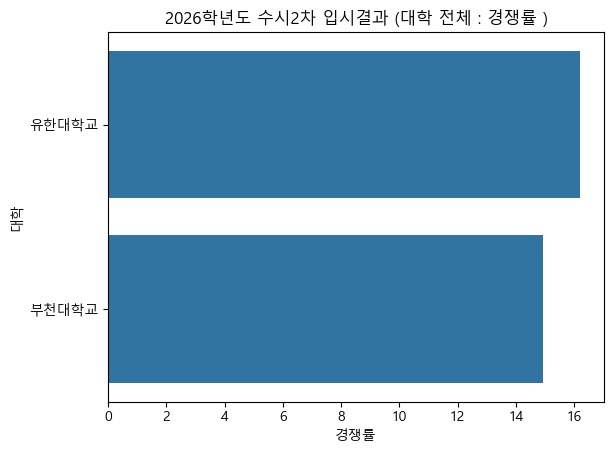

In [34]:
## 데이터프레임dml index를 컬럼으로 전환
sdf = df_tot.sort_values(by = '경쟁률', ascending=False)
sdf = sdf.reset_index()

## 데이터프레임으로 막대 그래프 그리기
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')  #폰트 사용
plt.title('2026학년도 수시2차 입시결과 (대학 전체 : 경쟁률 )')
sns.barplot(data=sdf, y = '대학', x = '경쟁률')

##### **4-2. [분석] 대학별 총 지원자 수 비교 그래프 그리기**
> 대학별 합계 총 지원자 수 순위 막대 그래프 그리기\
> 총지원인원이 많은 순으로 그리기

<Axes: title={'center': '2026학년도 수시2차 입시결과 (대학 전체 : 총지원자 수 )'}, xlabel='총지원인원', ylabel='대학'>

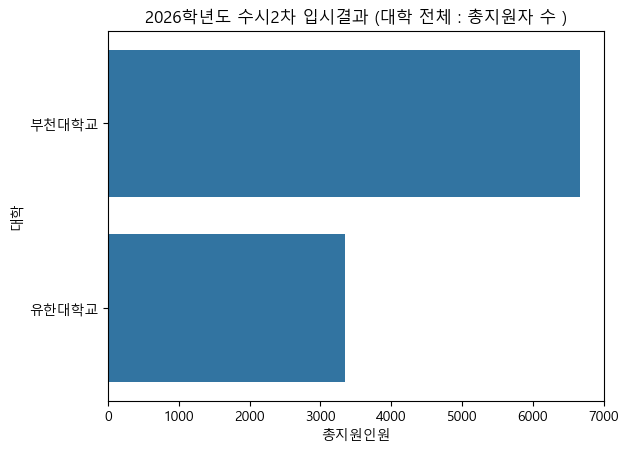

In [35]:
## 데이터프레임dml index를 컬럼으로 전환
sdf = df_tot.sort_values(by = '총지원인원', ascending=False)
sdf = sdf.reset_index()

## 데이터프레임으로 막대 그래프 그리기
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')  #폰트 사용
plt.title('2026학년도 수시2차 입시결과 (대학 전체 : 총지원자 수 )')
sns.barplot(data=sdf, y = '대학', x = '총지원인원')

### **[과제] Upgrade 하기**
#### 1. 기타 대학도 포함시키기 > *Upgrade 대상*
> 부천대학교, 유한대학교, 연성대학교, 대림대학교, 동서울대학교, 동양미래대학교
#### 2. 페이지 정보 데이터 프레임과 반복문을 활용하여 스크랩핑 > *Upgrade 대상*
##### > 페이지 정보 데이터 프레임 : 대학명, 페이지 url, 추출할 \<table> index로 구성
##### > 반복문 : 스크랩핑할 페이지 정보를 데이터 프레임으로부터 얻어 데이터 추출
> html에서 table[] 추출, 필요한 컬럼만 선택, 컬럼명 통일, '대학' 컬럼 추가, 행 병합 순으로 진행
#### 3. 데이터 조정 작업 > *[실습-1]과 동일*
##### > 경쟁률 데이터 값 보정하기 : 후반부의 ' : 1' 값 제거, 자료형을 float로 변경
##### > 불필요한 행 제거 : '전형' 컬럼에 '총계'나 '소계' 값이 들어있는 행은 삭제
##### > 컬럼 순서 조정 : ['대학', '전형', '모집인원', '지원인원', '경쟁률'] 순으로
#### 4. [분석] 대학별 합계 합계 경쟁률 데이터 구축 > *[실습-1]과 동일*
> 대학별 모집인원, 지원인원, 총지원인원, 경쟁률 컬럼으로 구성
#### 5. [분석] 대학별 합계 합계 경쟁률 비교 그래프 그리기 > *[실습-1]과 동일*
> 대학별 합계 경쟁률 순위 막대 그래프 그리기\
> 대학별 합계 지원자 수 순위 막대 그래프 그리기

----

##### **1. 기타 대학도 포함시키기** : 부천대학교, 유한대학교, 연성대학교, 대림대학교, 동서울대학교, 동양미래대학교
###### {'university' : ['부천대학교', '유한대학교', '연성대학교', 대림대학교, '동서울대학교', '동양미래대학교'],
######                    'url' : ['https://ratio.uwayapply.com/SmZKTEJKZkNDYUxKLWZUZg==',
######                             'https://ratio.uwayapply.com/SmZKVzh8OmJKZkNDYUxKLWZUZg==',
######                             'https://ratio.uwayapply.com/SmZKclc6JldhYGJKZkNDYUxKLWZUZg==',
######                             'https://ratio.uwayapply.com/SmZKTSVDYDhWSmZDQ2FMSi1mVGY=',
######                             'https://ratio.uwayapply.com/SmZKOlZKZkNDYUxKLWZUZg==',
######                             'https://addon.jinhakapply.com/RatioV1/RatioH/Ratio40580371.html' ]}
##### **2. 페이지 정보 데이터 프레임과 반복문을 활용하여 스크랩핑**
##### 페이지 정보 데이터 프레임 포함 사항
##### > 대학명, 수시2차 경쟁률 url, 사용할 Table index, 선택할 column들

In [65]:
## 페이지 정보 데이터 프레임 생성

## header 정보 초기화
                            
## 페이지 정보 데이터 프레임을 활용해 각 대학의 지원 현황 데이터를 추출하여 가공 후 새 데이터 프레임에 통합
df_all = pd.DataFrame()  # 하나로 통합할 데이터 프레임 생성

## 통합된 데이터 확인
df_all.tail()

부천대학교 (35, 6)
유한대학교 (38, 5)
연성대학교 (31, 5)
대림대학교 (28, 5)
동서울대학교 (36, 5)
동양미래대학교 (25, 4)


,전형,모집인원,지원인원,경쟁률,대학
30,치위생학과(3년제),5,117,23.40 : 1,부천대학교
31,응급구조학과(3년제),10,160,16.00 : 1,부천대학교
32,반려동물과,14,164,11.71 : 1,부천대학교
33,자율전공학과,3,74,24.67 : 1,부천대학교
34,소계,447,6674,14.93 : 1,부천대학교


In [66]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 193 entries, 0 to 34
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   전형      193 non-null    object
 1   모집인원    193 non-null    int64 
 2   지원인원    193 non-null    int64 
 3   경쟁률     193 non-null    object
 4   대학      193 non-null    object
dtypes: int64(2), object(3)
memory usage: 9.0+ KB


In [67]:
## [연습] 데이터 프레임의 모양 알아보기 : shape()
df_all.shape  #행과 열의 수를 반환

(193, 5)

##### **통합된 데이터를 파일로 저장**

In [68]:
## 통합된 데이터를 파일로 저장
import pandas as pd

df_all.to_excel('Ipsi_202602_all.xlsx', index=False)

##### **경쟁률 데이터 값 보정하기**
> 후반부의 ' : 1' 값 제거\
> 자료형을 float로 변경
##### **불필요한 행 제거**
> '전형' 컬럼에 '총계'나 '소계' 값이 들어있는 행은 삭제

In [69]:
#### '경쟁률' 컬럼 자료형을 float로 변경


## 불필요한 행 제거 : '전형' 컬럼에 '총계'나 '소계' 문자열이 포함된 행 제거

df_all

,전형,모집인원,지원인원,경쟁률,대학
0,기계공학과,27,165,6.11,동양미래대학교
1,기계설계공학과,27,167,6.19,동양미래대학교
2,자동화공학과(3년),19,181,9.53,동양미래대학교
3,로봇소프트웨어과(3년),19,139,7.32,동양미래대학교
4,전기공학과,27,233,8.63,동양미래대학교
...,...,...,...,...,...
29,치기공과(3년제),9,160,17.78,부천대학교
30,치위생학과(3년제),5,117,23.40,부천대학교
31,응급구조학과(3년제),10,160,16.00,부천대학교
32,반려동물과,14,164,11.71,부천대학교


##### **대학별 합계 합계 경쟁률 데이터 구축**
> 대학별 모집인원, 지원인원, 총지원인원, 경쟁률 컬럼으로 구성\
> 경쟁률이 높은 순으로 보기

In [70]:
##대학별 총모집인원, 총지원인원, 경쟁률 데이터 구축


,총모집인원,총지원인원,경쟁률
대학,,,
연성대학교,346,7364,21.283237
동서울대학교,223,3724,16.699552
유한대학교,206,3341,16.218447
부천대학교,447,6674,14.930649
대림대학교,325,4066,12.510769
동양미래대학교,509,3919,7.699411


##### **[분석] 대학별 합계 합계 경쟁률 비교 그래프 그리기**
> 경쟁율 내림차 순으로 그리기

<Axes: title={'center': '2026학년도 수시2차 입시결과 (대학 전체: 경쟁률)'}, xlabel='경쟁률', ylabel='대학'>

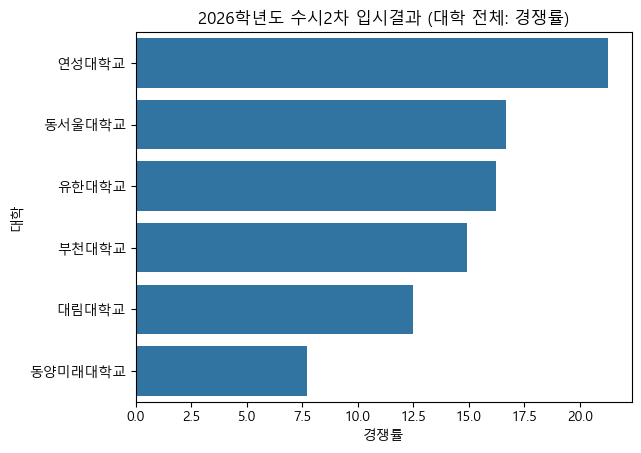

In [71]:
## 데이터프레임을 정렬하고, index를 컬럼으로 전환


## 데이터프레임으로 막대 그래프 그리기



##### **[분석] 대학별 합계 지원자 수 비교 그래프 그리기**
> 대학별 합계 총 지원자 수 순으로 그리기

<Axes: title={'center': '2026학년도 수시2차 입시결과 (대학 전체 : 총지원자 수 )'}, xlabel='총지원인원', ylabel='대학'>

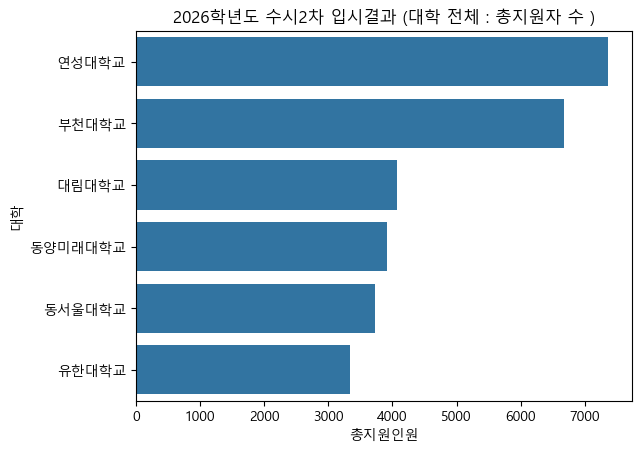

In [72]:
## 데이터프레임을 정렬하고, index를 컬럼으로 전환


## 데이터프레임으로 막대 그래프 그리기

